# <font color='#F5B167'> MD009 Estimación del error mediante simulación MC </font>

Cuando generamos números aleatorios a partir de una distribución de probabilidad, lo usual es que la muestra obtenida no tenga exactamente la misma media, varianza, etc. que la distribución teórica. Lo mismo pasa cuando medimos estos estadísticos a partir de una muestra de datos. Una manera de estimar cuál es el error estadístico de las cantidades que medimos, es generar mediante técnicas de Monte Carlo, N muestras y obtener de éstas cuál es realmente la desviación estándar.

**Un ejemplo:** A lo largo de un semestre un grupo de 100 estudiantes tienen la opción de entregar una serie de ejercicios (un máximo de 7), que se tendrán en cuenta para la nota de evaluación continua. El número de ejercicios entregados por cada estudiante es el siguiente:

In [1]:
nx = c(4, 4, 0, 3, 2, 1, 1, 6, 2, 2, 6, 4, 1, 5, 2, 2, 3, 4, 2, 2, 2, 3, 1, 0, 3, 3, 0, 0, 1, 6, 3, 3, 3, 3, 5, 1, 0, 0, 3, 1, 6, 3, 2, 2, 3, 3, 6, 1, 0, 4, 3, 1, 1, 5, 5, 2, 0, 3, 4, 1, 3, 7, 0, 3, 2, 2, 2, 3, 1, 1, 0, 4, 1, 1, 2, 2, 1, 2, 2, 2, 1, 3, 3, 5, 4, 4, 2, 2, 2, 3, 3, 2, 5, 5, 1, 1, 3, 1, 3, 1)

Si se realiza un histograma de los datos:

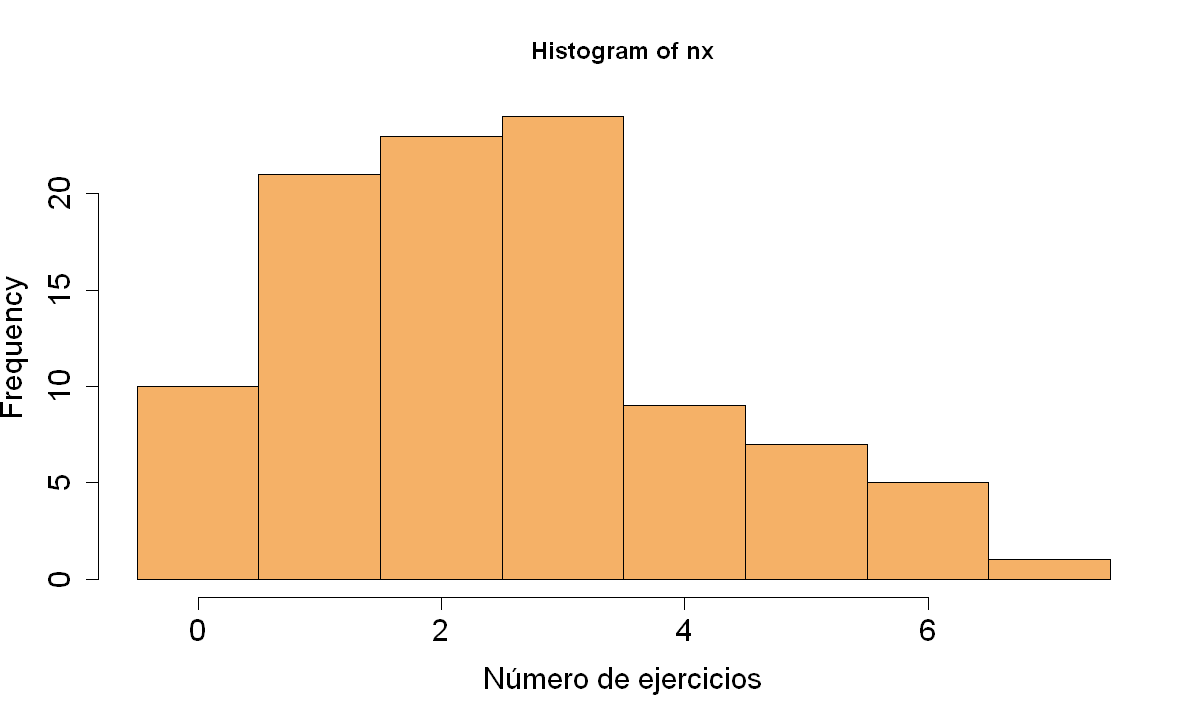

In [2]:
options(repr.plot.width = 10, repr.plot.height = 6)
xfreq <- hist(nx, breaks = c(seq(-0.5, 7.5, 1.0)), col = '#F5B167', xlab = 'Número de ejercicios', cex.lab = 1.5, cex.axis = 1.5)

In [3]:
mean(nx)

[1] 2.47

Viendo la distribución, podríamos plantearnos si sigue una distribución de Poisson, con $\lambda=2.47$. Lo comprobamos un un test chi-cuadrado.

In [4]:
chisq.test(xfreq$counts, p = dpois(xfreq$mids, lambda = mean(nx)), rescale.p = TRUE)
#xfreq$counts devuelve un vector con la cantidad de datos que hay en cada barra del histograma
#xfreq$mids devuelve un vector con el valor situado en la mitad de cada intervalo que componen las barras del hist

Warning message in chisq.test(xfreq$counts, p = dpois(xfreq$mids, lambda = mean(nx)), :
"Chi-squared approximation may be incorrect"



	Chi-squared test for given probabilities

data:  xfreq$counts
X-squared = 4.3018, df = 7, p-value = 0.7444


In [5]:
chi2_critico = qchisq(0.95, df = 7)
print(chi2_critico)

[1] 14.06714


Realizamos un ajuste a estos datos de una Poisson.

Loading required package: fitdistrplus

Loading required package: survival



Fitting of the distribution ' pois ' by maximum likelihood 
Parameters : 
       estimate Std. Error
lambda     2.47  0.1571623
Loglikelihood:  -186.1391   AIC:  374.2781   BIC:  376.8833 

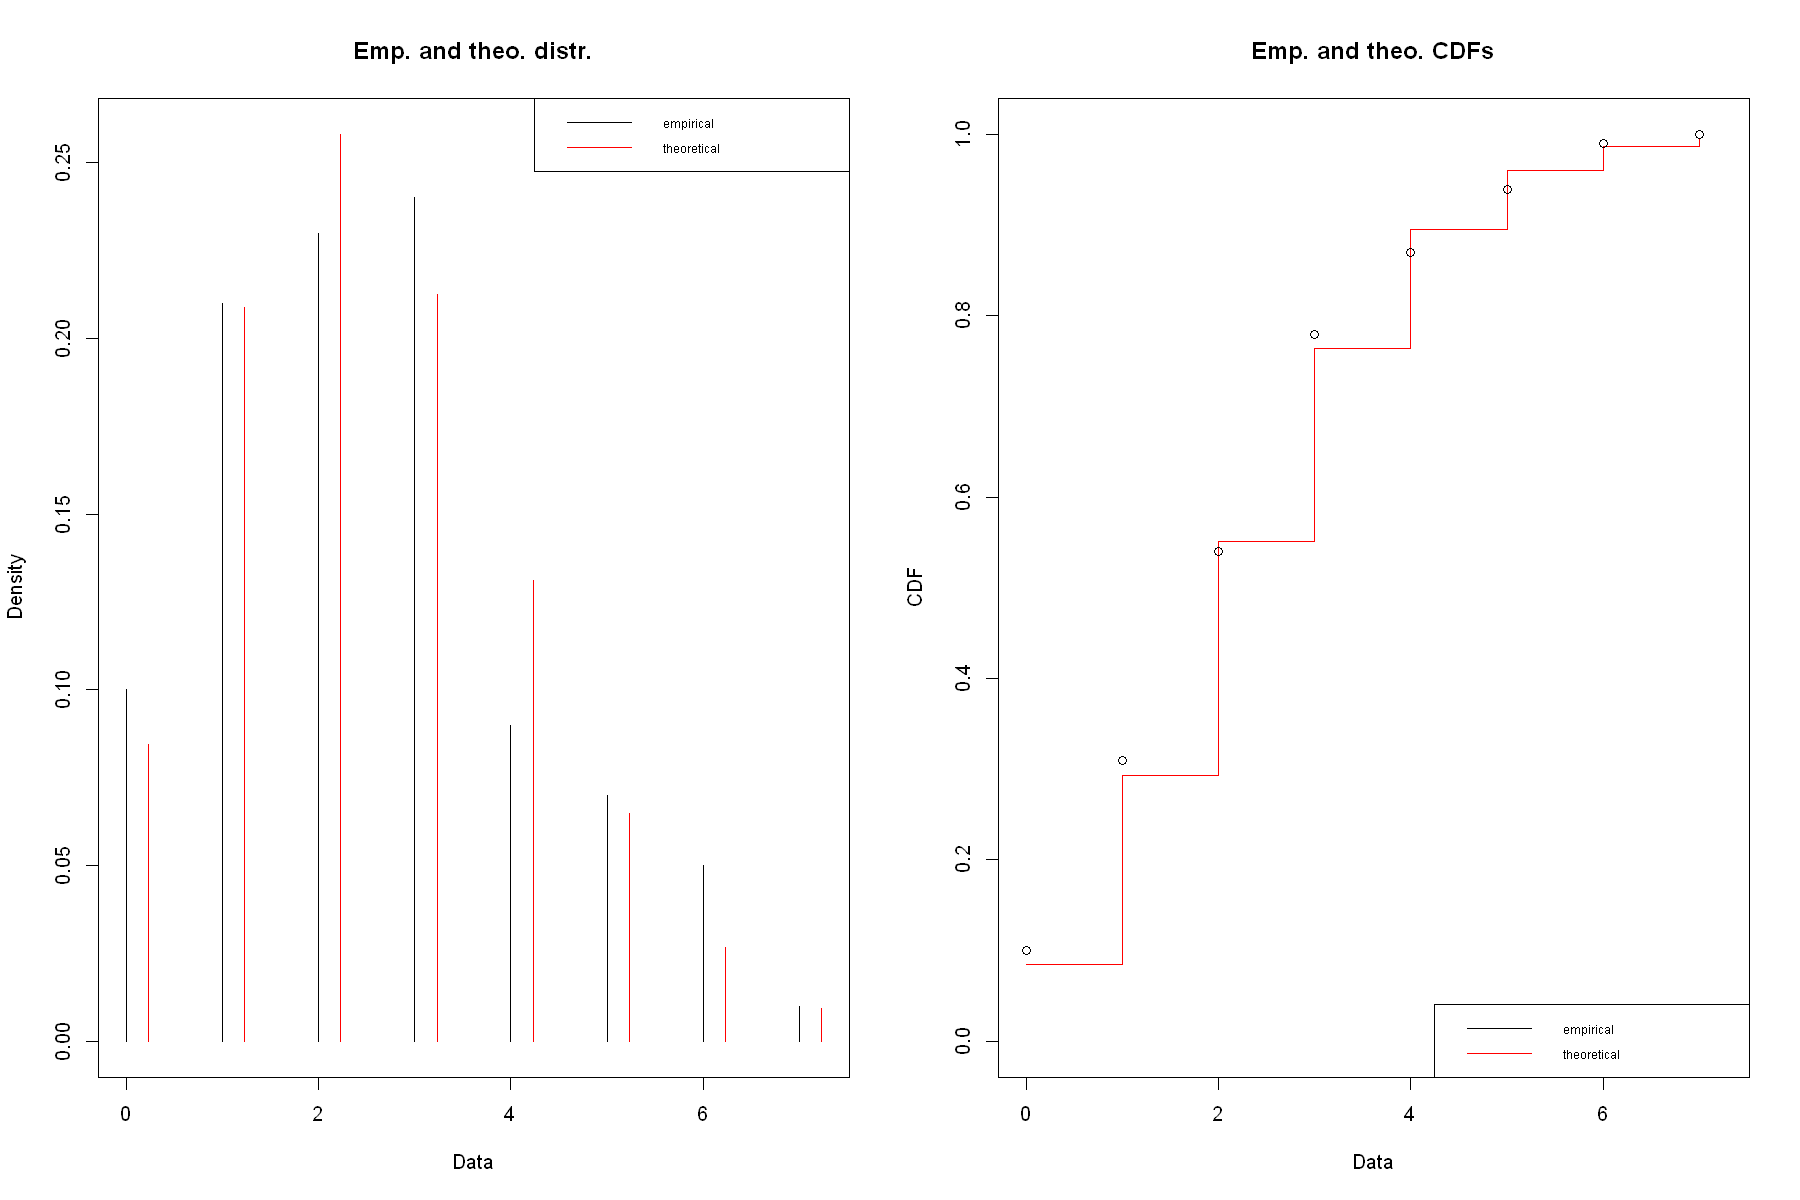

In [6]:
options(repr.plot.width = 15, repr.plot.height = 10)
library(MASS)
require(fitdistrplus)
fit1 <- fitdist(nx, "pois") #Ajustamos una distribución de Poisson a los datos
summary(fit1)
plot(fit1)

Obtenemos un valor de $\lambda=2.47\pm0.16$.

Efectivamente, los datos siguen una distribución de Poisson. De hecho, el número de ejercicios que había entregado cada estudiante se han generado a partir de una distribución de Poisson de media, $\lambda=2.5$. Si generásemos 1000 datasets distintos (cada uno de 100 estudiantes) y comparásemos la media de cada uno de ellos, deberíamos obtener una distribución gausiana centrada en 2.5 y cuya desviación estándar nos da la estimación del error estadístico de la media obtenida al analizar una sola muestra.

In [7]:
#Generamos 1000 datasets de 100 puntos según una Poisson
medias <- 0
for(k in 1:1000){
    nx = rpois(100, 2.5)
    medias[k] = mean(nx) #Guardamos la media de cada dataset en un vector
} 
mean(medias) #Calculamos la media del vector de medias
sd(medias) #Calculamos la desviación estándar del vector de medias

[1] 2.49997

[1] 0.1575281

Fitting of the distribution ' norm ' by maximum likelihood 
Parameters : 
      estimate  Std. Error
mean 2.4999700 0.004978986
sd   0.1574494 0.003520036
Loglikelihood:  429.7129   AIC:  -855.4258   BIC:  -845.6103 
Correlation matrix:
     mean sd
mean    1  0
sd      0  1


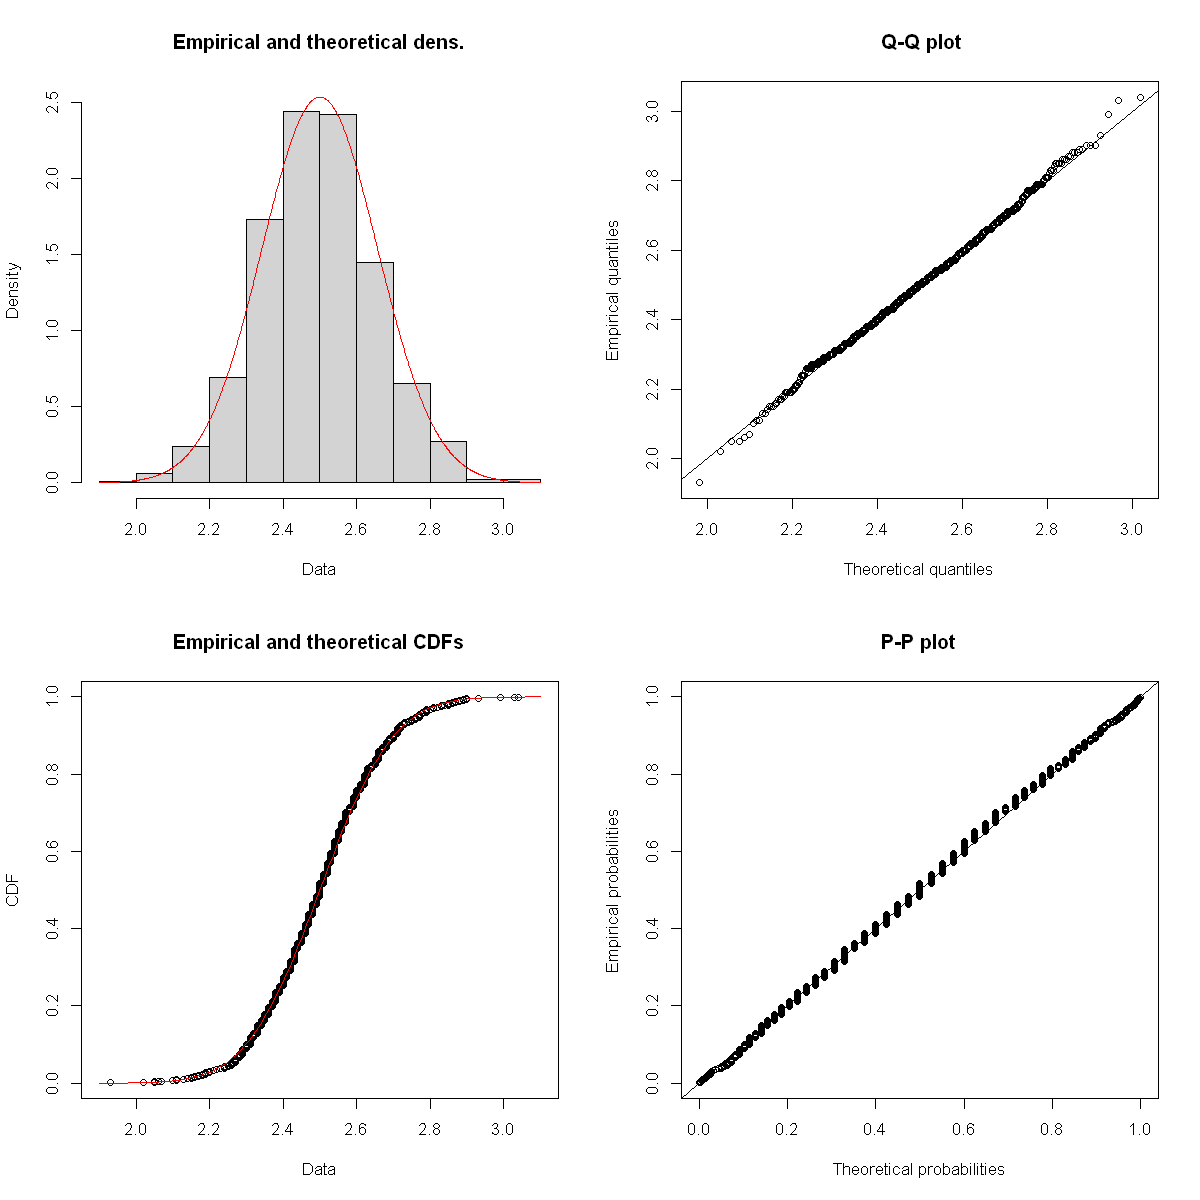

In [8]:
options(repr.plot.width = 10, repr.plot.height = 10)
#Ajuste gausiana
fit <- fitdist(medias, "norm") #Ajustamos el vector de medias a una distribución normal
summary(fit)
plot(fit)

Como era de esperar, en promedio, el valor de $\lambda$ obtenido es compatible con el 2.5 real utilizado para generar los números aleatorios. Y el error estadístico de éste, sería el 0.16. Compatible con el error obtenido al hacer el ajuste de una Poisson sobre uno de esos datasets individualmente (i.e. el método de maximum likelihood utilizado estima correctamente el error). Cogiendo como ejemplo el último dataset:

Fitting of the distribution ' pois ' by maximum likelihood 
Parameters : 
       estimate Std. Error
lambda     2.67  0.1634013
Loglikelihood:  -185.4338   AIC:  372.8676   BIC:  375.4727 

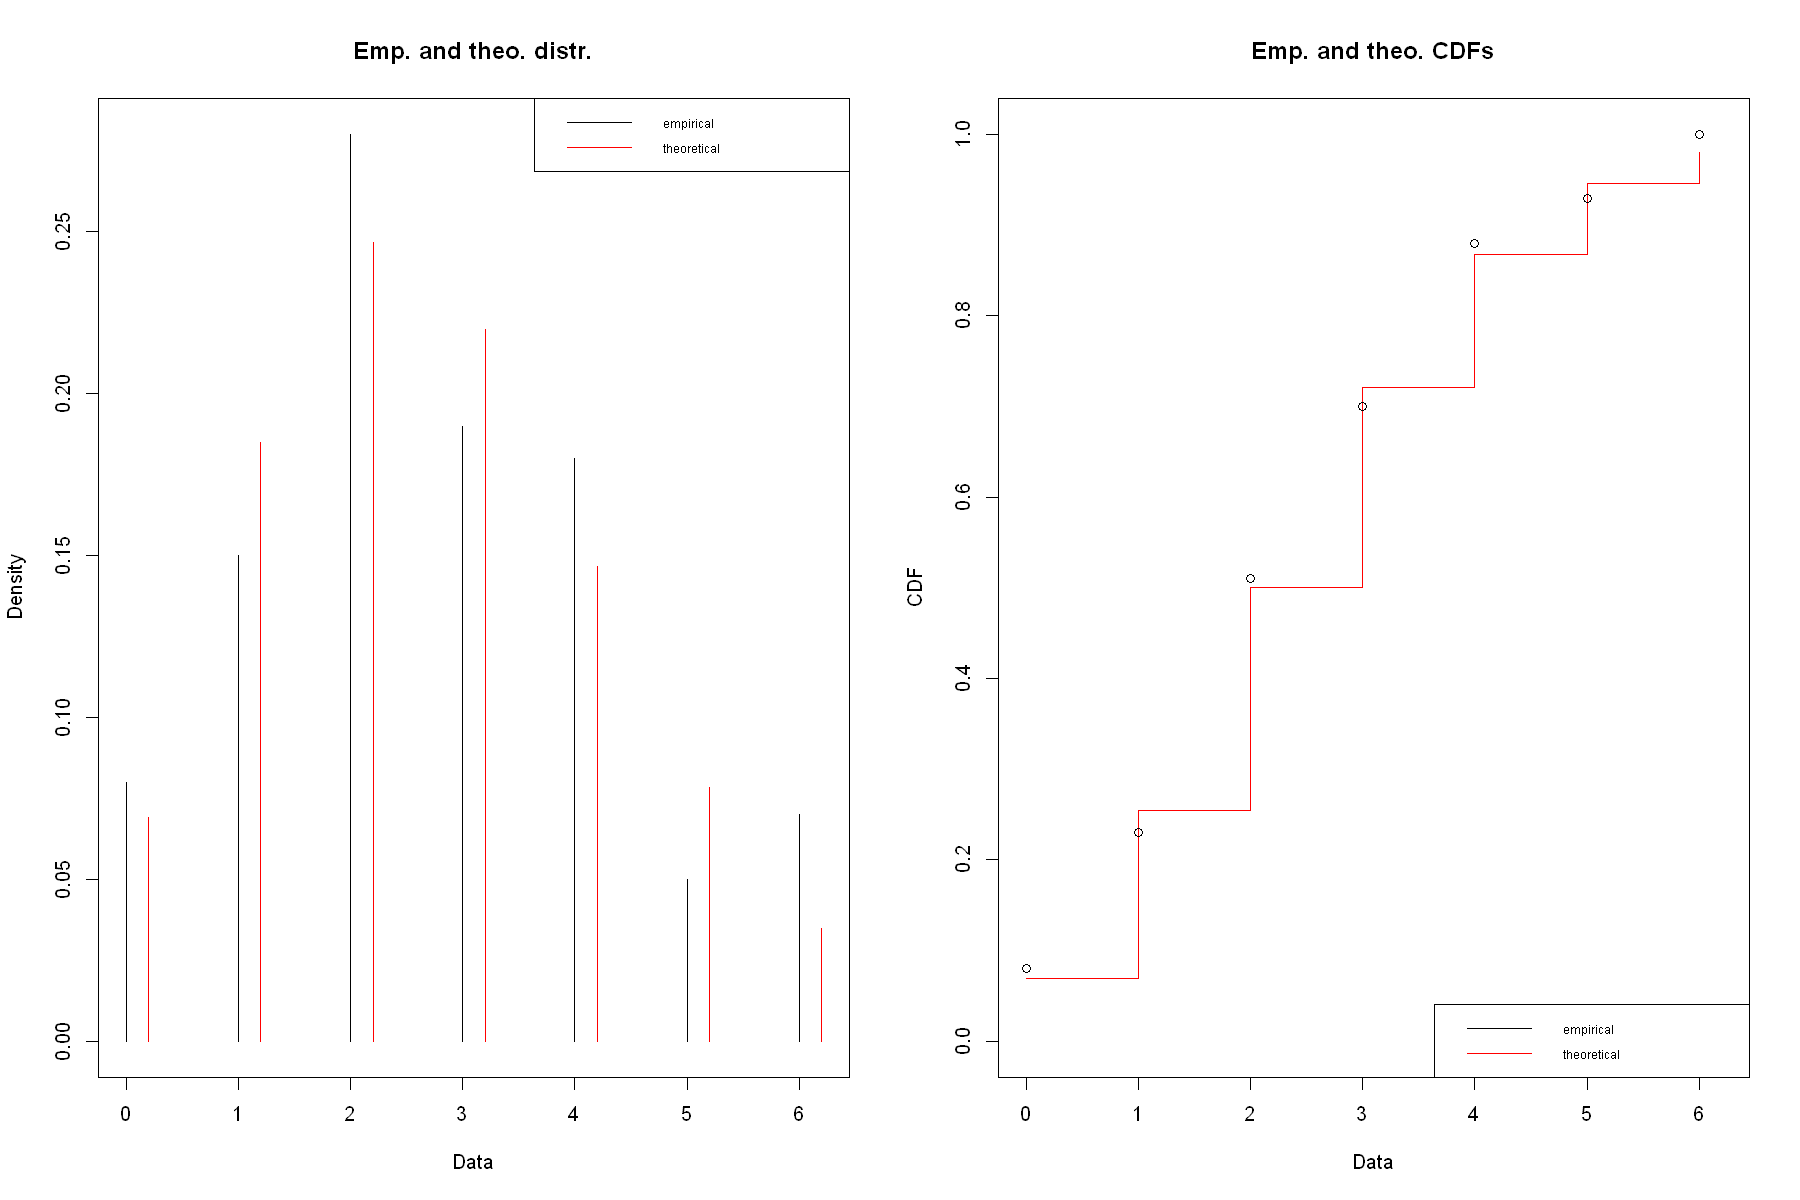

In [9]:
options(repr.plot.width = 15, repr.plot.height = 10)
fit2 <- fitdist(nx, "pois") #Ajustamos el último dataset generado a una distribución de Poisson
summary(fit2)
plot(fit2)